1. Introducción:
Este proyecto es un informe de análisis exploratorio de datos (EDA) sobre las ventas globales de una plataforma de vehículos entre enero de 2003 y junio de 2005. Los productos comercializados por la plataforma incluyen automóviles clásicos, coches antiguos, motocicletas, aviones, camiones, autobuses y trenes. Su base de clientes abarca 19 países, entre ellos Estados Unidos, Japón y Singapur. La base de datos contiene indicadores clave para el análisis EDA, tales como la cantidad de pedidos, el producto, el precio unitario, el país y las ventas netas.

En este informe de análisis EDA, me enfocaré en analizar detalladamente las ventas de los diferentes productos por país, las tendencias de las ventas a lo largo del tiempo y la relación entre el precio unitario del producto y el volumen de pedidos.

In [235]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# loading the dataset
df = pd.read_csv('sales_data_sample.csv', encoding='latin1')

# dataset overview
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [236]:
# dataset basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


2. Preparación de datos
Durante esta fase de preparación de datos, mi objetivo es realizar la limpieza y organización de la base de datos original. Esto incluye principalmente el tratamiento de datos faltantes y duplicados, la validación de los tipos de datos y la eliminación de aquellos contenidos que no aportan valor analítico para este EDA.

In [323]:
# detection of duplicates
print(df.duplicated().sum())

0


In [324]:
# detection of missing data
print(df.isnull().sum())

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY              0
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64


Justificación: Los resultados muestran que los datos faltantes se concentran en cuatro columnas: 'state', 'address line 2', 'postal code' y 'territory'. Dado que el enfoque de este informe EDA es el análisis a nivel geográfico por país, procederé a eliminar las columnas 'state' y 'postal code'. Asimismo, debido a que este informe no incluye un análisis profundo de CRM, la columna 'address line 2' también será eliminada. En cuanto a la variable 'territory', realizaré una calibración y completado de datos tomando como referencia el país correspondiente.

Se realizará una imputación de datos en la columna 'territory' utilizando la columna de país como referencia, ya que esta última no presenta valores nulos.

In [325]:
print(df['TERRITORY'].value_counts())

TERRITORY
EMEA       1407
America    1074
APAC        342
Name: count, dtype: int64


In [326]:
print(df['COUNTRY'].unique())
print(len(df['COUNTRY'].unique()))

['USA' 'France' 'Norway' 'Australia' 'Finland' 'Austria' 'UK' 'Spain'
 'Sweden' 'Singapore' 'Canada' 'Japan' 'Italy' 'Denmark' 'Belgium'
 'Philippines' 'Germany' 'Switzerland' 'Ireland']
19


In [327]:
print(df[df['TERRITORY'] == 'EMEA'].COUNTRY.value_counts())

COUNTRY
Spain          342
France         314
UK             144
Italy          113
Finland         92
Norway          85
Denmark         63
Germany         62
Sweden          57
Austria         55
Belgium         33
Switzerland     31
Ireland         16
Name: count, dtype: int64


In [328]:
print(df[df['TERRITORY'] == 'APAC'].COUNTRY.value_counts())
print(len(df[df['TERRITORY'] == 'APAC']))

COUNTRY
Australia      185
Singapore       79
Japan           52
Philippines     26
Name: count, dtype: int64
342


In [329]:
print(df[df['TERRITORY'] == 'Japan'].COUNTRY.value_counts())
print(len(df[df['TERRITORY'] == 'Japan']))

Series([], Name: count, dtype: int64)
0


Se han detectado errores evidentes en la segmentación de las regiones de ventas en la base de datos; la columna 'TERRITORY' no sigue una clasificación coherente entre EMEA, APAC y Americas. Además, Singapur aparece registrado simultáneamente en dos territorios distintos. Por lo tanto, mi lógica de corrección consistirá en reclasificar el territorio de todos los países existentes, enfocándome especialmente en la asignación correcta de 'Americas' y en la reorganización de 'APAC'.

In [330]:
df.loc[df['COUNTRY'] == 'USA', 'TERRITORY'] = 'America'
df.loc[df['COUNTRY'] == 'Canada', 'TERRITORY'] = 'America'
df.loc[df['COUNTRY'] == 'Singapore', 'TERRITORY'] = 'APAC'
df.loc[df['COUNTRY'] == 'Japan', 'TERRITORY'] = 'APAC'
df.loc[df['COUNTRY'] == 'Philippines', 'TERRITORY'] = 'APAC'

In [331]:
# review of missing data
print(df.isnull().sum())

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY              0
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64


In [332]:
# review the territory column
print(df['TERRITORY'].value_counts())

TERRITORY
EMEA       1407
America    1074
APAC        342
Name: count, dtype: int64


In [333]:
# dropping unnecesary column
df_clean = df.drop(columns=['ORDERNUMBER','ORDERLINENUMBER','ADDRESSLINE2','PRODUCTCODE','ADDRESSLINE1', 'STATUS','PHONE', 'CITY','STATE','POSTALCODE','CONTACTLASTNAME', 'CONTACTFIRSTNAME','CUSTOMERNAME'])
df_clean.head()

,QUANTITYORDERED,PRICEEACH,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,COUNTRY,TERRITORY,DEALSIZE
0,30,95.70,2871.00,2/24/2003 0:00,1,2,2003,Motorcycles,95,USA,America,Small
1,34,81.35,2765.90,5/7/2003 0:00,2,5,2003,Motorcycles,95,France,EMEA,Small
2,41,94.74,3884.34,7/1/2003 0:00,3,7,2003,Motorcycles,95,France,EMEA,Medium
3,45,83.26,3746.70,8/25/2003 0:00,3,8,2003,Motorcycles,95,USA,America,Medium
4,49,100.00,5205.27,10/10/2003 0:00,4,10,2003,Motorcycles,95,USA,America,Medium


In [334]:
# review data type
df_clean.info()
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   QUANTITYORDERED  2823 non-null   int64  
 1   PRICEEACH        2823 non-null   float64
 2   SALES            2823 non-null   float64
 3   ORDERDATE        2823 non-null   object 
 4   QTR_ID           2823 non-null   int64  
 5   MONTH_ID         2823 non-null   int64  
 6   YEAR_ID          2823 non-null   int64  
 7   PRODUCTLINE      2823 non-null   object 
 8   MSRP             2823 non-null   int64  
 9   COUNTRY          2823 non-null   object 
 10  TERRITORY        2823 non-null   object 
 11  DEALSIZE         2823 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 264.8+ KB


,QUANTITYORDERED,PRICEEACH,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,35.092809,83.658544,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,9.741443,20.174277,1841.865106,1.203878,3.656633,0.69967,40.187912
min,6.000000,26.880000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,27.000000,68.860000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,35.000000,95.700000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,43.000000,100.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,97.000000,100.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [335]:
# change the data type of date
df_clean['ORDERDATE'] = pd.to_datetime(df_clean['ORDERDATE'])

Tras la limpieza y organización de la base de datos, el DataFrame incluye variables como la cantidad vendida, el precio unitario, la línea de producto, la fecha de venta, el país, el territorio y el Precio de Venta Sugerido por el Fabricante (MSRP). A partir del MSRP y del precio de venta real, me propongo crear un nuevo indicador sintético denominado 'MSRP GAP'. Este indicador representa la diferencia entre el MSRP y el precio de venta final, y se utilizará para medir la capacidad de control de precios de la plataforma de ventas.

In [336]:
# create a new column called MSRP GAP
df_clean['MSRP GAP'] = df_clean['MSRP'] - df_clean['PRICEEACH']
df_clean.head()

,QUANTITYORDERED,PRICEEACH,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,COUNTRY,TERRITORY,DEALSIZE,MSRP GAP
0,30,95.70,2871.00,2003-02-24,1,2,2003,Motorcycles,95,USA,America,Small,-0.70
1,34,81.35,2765.90,2003-05-07,2,5,2003,Motorcycles,95,France,EMEA,Small,13.65
2,41,94.74,3884.34,2003-07-01,3,7,2003,Motorcycles,95,France,EMEA,Medium,0.26
3,45,83.26,3746.70,2003-08-25,3,8,2003,Motorcycles,95,USA,America,Medium,11.74
4,49,100.00,5205.27,2003-10-10,4,10,2003,Motorcycles,95,USA,America,Medium,-5.00


3. Análisis Cuantitativo
En esta etapa del análisis cuantitativo, exploraré la distribución y los patrones de los datos relativos a la cantidad de pedidos, las ventas y el precio unitario. Asimismo, identificaré los valores atípicos (outliers) en los datos cuantitativos, realizaré su tratamiento de estandarización y llevaré a cabo un análisis de perfilado (profiling) por grupos para comprender las características de estos valores extremos.

3.1 Análisis de QUANTITYORDERED

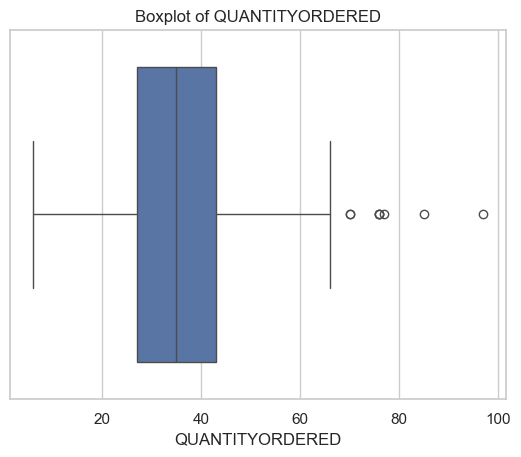

In [337]:
# boxplot of 'QUANTITYORDERED'
plt.figure()
sns.boxplot(x=df_clean['QUANTITYORDERED'])
plt.title('Boxplot of QUANTITYORDERED')
plt.xlabel('QUANTITYORDERED')
plt.show()
plt.savefig('quantity_ordered_boxplot.png')
plt.close()

In [365]:
# Statistic feature of 'QUANTITYORDERED'
print(f"Mean: {df_clean['QUANTITYORDERED'].mean():.2f}")
print(f"Median: {df_clean['QUANTITYORDERED'].median():.2f}")
print(f"Mode: {df_clean['QUANTITYORDERED'].mode()[0]:.2f}")
print(f"Standard deviation: {df_clean['QUANTITYORDERED'].std():.2f}")
print(f"Variance: {df_clean['QUANTITYORDERED'].var():.2f}")

Mean: 35.09
Median: 35.00
Mode: 34.00
Standard deviation: 9.74
Variance: 94.90


A juzgar por la distribución de los datos de la cantidad de pedidos, existen valores atípicos (outliers), pero su volumen es reducido, por lo que no se requiere un análisis por grupos. En consecuencia, aplicaré un proceso de estandarización a estos valores atípicos con el fin de utilizarlos en el análisis de correlación posterior y en los modelos de aprendizaje automático (machine learning).

In [366]:
# calculate the outlier thresholds for QUANTITYORDERED
Q1 = df_clean['QUANTITYORDERED'].quantile(0.25)
Q3 = df_clean['QUANTITYORDERED'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'QUANTITYORDERED Outlier Thresholds: Lower = {lower_bound}, Upper = {upper_bound}')
print(len(df[df['QUANTITYORDERED'] > upper_bound]))

QUANTITYORDERED Outlier Thresholds: Lower = 3.0, Upper = 67.0
8


In [368]:
# standerdize the 'QUANTITYORDERED'
df_clean['QUANTITYORDERED_STD'] = (df_clean['QUANTITYORDERED'] - df_clean['QUANTITYORDERED'].mean()) / df_clean['QUANTITYORDERED'].std()

3.2 Análisis de SALES

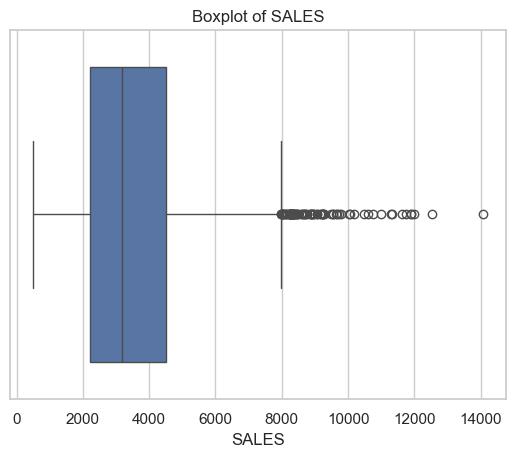

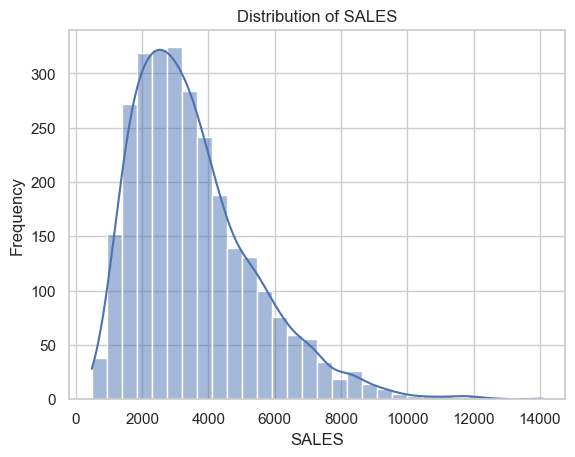

In [369]:
# boxplot of 'SALES'
plt.figure()
sns.boxplot(x=df_clean['SALES'])
plt.title('Boxplot of SALES') 
plt.xlabel('SALES')
plt.show()
plt.savefig('sales_boxplot.png')
plt.close()

# histagram of 'SALES'
sns.histplot(df_clean['SALES'], bins=30, kde=True)
plt.title('Distribution of SALES')
plt.xlabel('SALES')
plt.ylabel('Frequency')
plt.show()
plt.savefig('sales_distribution.png')
plt.close()

Al analizar la distribución de los datos de ventas, se observa la presencia de valores atípicos (outliers) que se caracterizan por ser numerosos, presentar una amplia dispersión y estar concentrados en un segmento específico de los datos. Por lo tanto, realizaré un procesamiento por grupos para la variable de ventas, clasificándola en un 'grupo estándar' y un 'grupo de alto valor'.

In [370]:
# calculate the outlier thresholds for SALES
Q1_sales = df_clean['SALES'].quantile(0.25) 
Q3_sales = df_clean['SALES'].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales
lower_bound_sales = Q1_sales - 1.5 * IQR_sales
upper_bound_sales = Q3_sales + 1.5 * IQR_sales
print(f'SALES Outlier Thresholds: Lower = {lower_bound_sales}, Upper = {upper_bound_sales}')

SALES Outlier Thresholds: Lower = -1253.4249999999993, Upper = 7964.855


In [372]:
# segmentation of 'STANDARD' and 'HIGH VALUE'
df_clean.loc[df['SALES'] <=  7964.855, 'SEGMENTATION'] = 'Satndard'
df_clean.loc[df['SALES'] > 7964.855, 'SEGMENTATION'] = 'High Value'

In [373]:
# statictic feature of sales overall
df_clean['SALES'].describe()

count     2823.000000
mean      3553.889072
std       1841.865106
min        482.130000
25%       2203.430000
50%       3184.800000
75%       4508.000000
max      14082.800000
Name: SALES, dtype: float64

In [374]:
# statistic feature of sales from different group
df_clean.groupby(['SEGMENTATION']).SALES.describe()

,count,mean,std,min,25%,50%,75%,max
SEGMENTATION,,,,,,,,
High Value,81.0,9172.200988,1259.948896,7969.36,8289.050,8714.700,9558.8000,14082.80
Satndard,2742.0,3387.921433,1576.715785,482.13,2173.805,3141.585,4351.2125,7962.24


En relación con los datos agrupados de ventas, los resultados muestran con gran claridad la aplicación de la 'Ley de Pareto' (Principio del 80/20) en la plataforma de venta de vehículos. Al realizar la detección de valores atípicos en el monto de ventas (SALES) y clasificarlos en 'High Value' (Grupo de alto valor) y 'Standard' (Grupo convencional), podemos observar diferencias operativas significativas:

1. Estructura de contribución al negocioGrupo Convencional (Standard): Representa la gran mayoría del volumen de pedidos ($2742$ transacciones) con una media aproximada de $\$3388$. Este grupo refleja un comportamiento de venta minorista estable y recurrente.Grupo de Alto Valor (High Value): Aunque solo cuenta con $81$ pedidos (aproximadamente el $2.8\%$ del total), su media alcanza los $\$9172$, lo que equivale a $2.7$ veces el promedio del grupo estándar.

2. Distribución de los intervalos de valorEl umbral para los pedidos de alto valor (Min) comienza en los $\$7969$ y llega hasta un máximo de $\$14082$ por transacción.Mientras que el grupo estándar muestra una alta volatilidad (desviación estándar de $1576$), los montos en el grupo de alto valor están relativamente concentrados entre los $\$8289$ y $\$9558$ (percentiles $25\%$ y $75\%$). Esto sugiere que el grupo de alto valor podría estar vinculado a compras corporativas estandarizadas o paquetes de consumo premium específicos.

Estos $81$ valores atípicos no representan errores en los datos, sino que constituyen el núcleo de rentabilidad de la plataforma. A pesar de su baja participación en el volumen total de pedidos, aportan una altísima densidad de ingresos por transacción.

Realizaré un análisis detallado del perfil del grupo de alto valor en la quinta sección: 'Análisis Multivariante Clave' (Key Multivariate Analysis).

3.3. Análisis de PRICEEACH

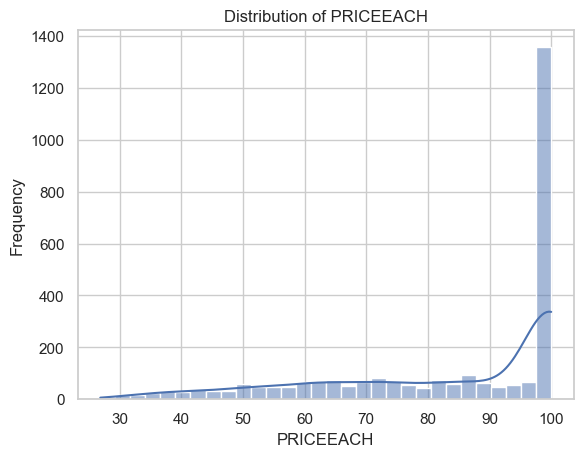

<Figure size 640x480 with 0 Axes>

In [375]:
# visualize the histagram of PRICEEACH
plt.figure()
sns.histplot(df_clean['PRICEEACH'], bins=30, kde=True)
plt.title('Distribution of PRICEEACH')
plt.xlabel('PRICEEACH')
plt.ylabel('Frequency')
plt.show()
plt.savefig('price_each_distribution.png')

La distribución del precio unitario en este conjunto de datos presenta un sesgo extremo a la izquierda (Left-Skewed), con una saturación muy alta en el valor de 100. Esto indica un claro efecto de 'techo de precios' en la plataforma. Dado que el análisis tradicional de medias no logra reflejar la lógica real del negocio debido a esta saturación en 100, este informe descarta el uso de la media o mediana convencional y opta por el método de segmentación por rangos o 'Price Binning'. He definido el intervalo inferior a 40 como 'Bottom Outliers'. El análisis revela que, a pesar de su bajo precio unitario, las características de los pedidos de este grupo difieren significativamente del resto del negocio. Esta estratificación nos permite eliminar el ruido de los precios bajos y observar con mayor precisión el rendimiento del núcleo operativo en el rango de precios principal (80-100).

In [376]:
# Identify bins and label
bins = [0, 40, 80, 99, 101]
labels = ['Bottom Outlier', 'Budget', 'Mainstream', 'Core High']

# Create new column 'Price_Gorup'
df_clean['Price_Group'] = pd.cut(df_clean['PRICEEACH'], bins=bins, labels=labels, right=False)
# Statictic of different group
df_clean.groupby('Price_Group').PRICEEACH.describe()

C:\Users\ayidi\AppData\Local\Temp\ipykernel_18496\2189772235.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('Price_Group').PRICEEACH.describe()


,count,mean,std,min,25%,50%,75%,max
Price_Group,,,,,,,,
Bottom Outlier,102.0,34.886373,3.298295,26.88,32.5000,35.755,37.1775,39.83
Budget,900.0,62.130167,10.788064,40.15,53.4625,63.075,71.2725,79.98
Mainstream,494.0,89.077085,5.437907,80.00,84.7100,88.340,94.1400,98.99
Core High,1327.0,99.991281,0.072216,99.04,100.0000,100.000,100.0000,100.00


Dominio Absoluto (Core High): Esta es la característica más sorprendente de la plataforma. $1,327$ pedidos (aproximadamente el $47\%$ del total) tienen un precio unitario fijado con precisión entre $99.04$ y $100$, con una desviación estándar de apenas $0.07$. Esto confirma la existencia de una estrategia de precios extremadamente estandarizada para los productos estrella (best-sellers).

Mainstream (Grupo Principal): Con un precio promedio de $89$ y una desviación estándar reducida ($5.4$), este segmento representa la línea estable de productos de gama media-alta.

Budget (Grupo Económico): Con un precio promedio de $62$ y un volumen de $900$ pedidos, es el motor principal que cubre el mercado medio de la plataforma.

Identificación de Valores Atípicos Inferiores (Bottom Outlier): Este segmento consta de $102$ pedidos con un precio promedio de solo $34.8$. Dado que sus precios son significativamente inferiores a las líneas de productos principales y su volumen es reducido, deben ser tratados como ruido en el análisis global de ventas de la plataforma.

4. Análisis Categórico:
En esta fase, realizaré un análisis del volumen de pedidos y la cuota de ventas por país, producto y territorio. Asimismo, analizaré las preferencias de productos en los cinco países con mayor volumen de ventas. Finalmente, llevaré a cabo un análisis dinámico de los datos de ventas con una periodicidad anual y mensual.

4.1 Ventas por país y territorio

In [377]:
# aggregated numbers of orderquantity and sales of each country
country_summary = df_clean.groupby('COUNTRY').agg({
    'SALES': ['sum', 'mean', 'median'],
    'QUANTITYORDERED': ['sum', 'mean']
})
country_summary

SALES                        QUANTITYORDERED           
                    sum         mean    median             sum       mean
COUNTRY                                                                  
Australia     630623.10  3408.773514  3070.400            6246  33.762162
Austria       202062.53  3673.864182  3307.200            1974  35.890909
Belgium       108412.62  3285.230909  2796.120            1074  32.545455
Canada        224078.56  3201.122286  2982.950            2293  32.757143
Denmark       245637.15  3899.002381  3193.520            2197  34.873016
Finland       329581.91  3582.412065  3247.830            3192  34.695652
France       1110916.52  3537.950701  3154.305           11090  35.318471
Germany       220472.09  3556.001452  3271.200            2148  34.645161
Ireland        57756.43  3609.776875  3419.965             490  30.625000
Italy         374674.31  3315.701858  2915.660            3773  33.389381
Japan         188167.81  3618.611731  2923.430            1842  35.423077
Norway        307463.70  3617.220000  3394.980            2842  33.435294
Philippines    94015.73  3615.989615  3329.310             961  36.961538
Singapore     288488.41  3651.752025  3127.880            2760  34.936709
Spain        1215686.92  3554.640117  3213.805           12429  36.342105
Sweden        210014.21  3684.459825  3256.960            2006  35.192982
Switzerland   117713.56  3797.211613  3540.530            1078  34.774194
UK            478880.46  3325.558750  3122.470            5013  34.812500
USA          3627982.83  3613.528715  3236.060           35659  35.516932

In [378]:
# statistic feature of orderquantity and sales of each territory
territory_summary = df_clean.groupby('TERRITORY').agg({
    'SALES': ['sum', 'mean', 'median'],
    'QUANTITYORDERED': ['sum', 'mean']
}).reset_index()
territory_summary

TERRITORY       SALES                        QUANTITYORDERED           
                    sum         mean    median             sum       mean
0      APAC  1201295.05  3512.558626  3062.485           11809  34.529240
1   America  3852061.39  3586.649339  3209.250           37952  35.337058
2      EMEA  4979272.41  3538.928507  3187.800           49306  35.043355

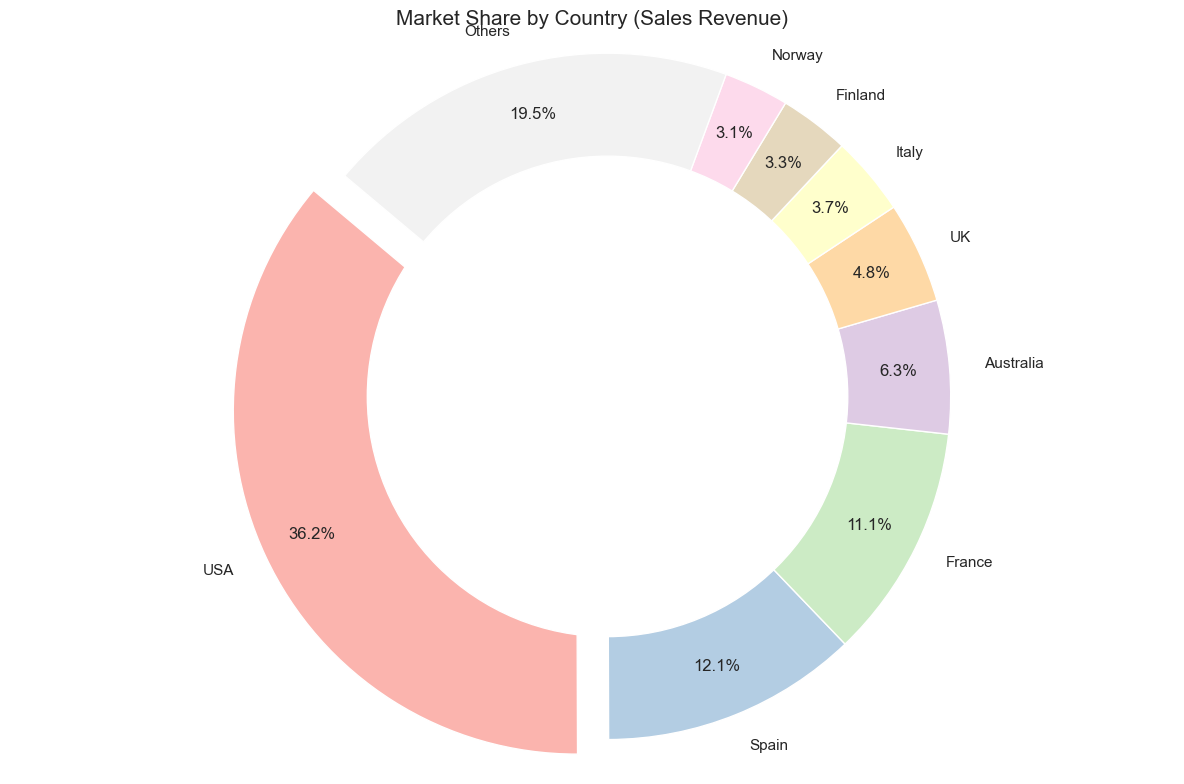

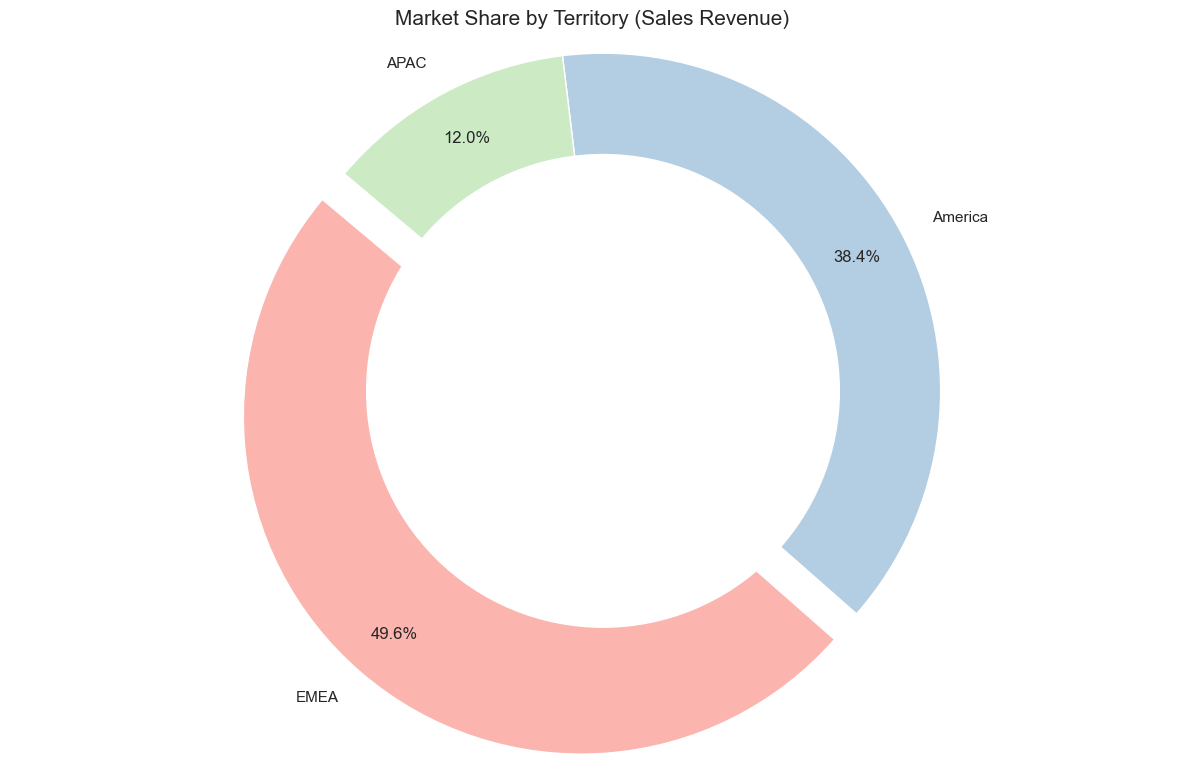

In [379]:
# 1. calculate the aggregated sum of sale from different countries
country_sales = df_clean.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)

# 2. prepare the data for the piechart Market Share by Country (Sales Revenue)
top_n = 8
plot_data = country_sales.head(top_n)
others_sales = country_sales.iloc[top_n:].sum()
plot_data['Others'] = others_sales

# 3. visualize the piechart
plt.figure(figsize=(12, 8))
colors = plt.get_cmap('Pastel1').colors
plt.pie(plot_data, 
        labels=plot_data.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        pctdistance=0.85, 
        explode=[0.1 if i == 0 else 0 for i in range(len(plot_data))]) 
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Market Share by Country (Sales Revenue)', fontsize=15)
plt.axis('equal') 
plt.tight_layout()
plt.show()

# 1. calculate the aggregated sum of sale from different territory
territory_sales = df_clean.groupby('TERRITORY')['SALES'].sum().sort_values(ascending=False)

# 3. visualize the piechart Market Share by Territory (Sales Revenue
plt.figure(figsize=(12, 8))
colors = plt.get_cmap('Pastel1').colors
plt.pie(territory_sales, 
        labels=territory_sales.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        pctdistance=0.85, 
        explode=[0.1 if i == 0 else 0 for i in range(len(territory_sales))]) 
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Market Share by Territory (Sales Revenue)', fontsize=15)
plt.axis('equal') 
plt.tight_layout()
plt.show()

Mercado por Países: El Liderazgo Central de USA
A juzgar por el gráfico de anillos, la distribución de los ingresos a nivel geográfico presenta una estructura de "una superpotencia y múltiples seguidores":
1. Primer Mercado: USA ocupa el primer lugar en ventas con una ventaja absoluta del 36.2%.
2. Seguidores Clave: España (12.1%), Francia (11.1%) y Australia (6.3%) le siguen de cerca.
3. Dispersión Regional: El resto de los países fuera del Top 8 (Others) suman un 19.5%, lo que demuestra que el negocio posee una amplitud global considerable.

Territorios Regionales: La Rivalidad entre EMEA y Americas
Al segmentar por regiones, el centro de gravedad de los ingresos es muy claro:
1. EMEA (Europa, Oriente Medio y África): Aporta casi la mitad de los ingresos (49.6%), consolidándose como la región operativa más importante para la plataforma.
2. Americas (América): Representa el 38.4%, posicionándose en un sólido segundo lugar.
3. APAC (Asia-Pacífico): Actualmente representa solo el 12.0%. Aunque ocupa una posición minoritaria, esto sugiere un margen potencial para el crecimiento futuro.

4.2 Análisis de Productos

In [388]:
# create the product summary
product_summary = df_clean.groupby('PRODUCTLINE').agg({
    'SALES': ['sum', 'mean', 'median'],
    'QUANTITYORDERED': ['sum', 'mean'],
    'MSRP GAP': ['mean', 'median']
})
product_summary

SALES                        QUANTITYORDERED  \
                         sum         mean    median             sum   
PRODUCTLINE                                                           
Classic Cars      3919615.66  4053.377104  3761.370           33992   
Motorcycles       1166388.34  3523.831843  3127.820           11663   
Planes             975003.57  3186.286176  2841.805           10727   
Ships              714437.13  3053.150128  2884.925            8127   
Trains             226243.47  2938.226883  2445.600            2712   
Trucks and Buses  1127789.84  3746.810100  3449.400           10777   
Vintage Cars      1903150.84  3135.339110  2795.270           21069   

                              MSRP GAP          
                       mean       mean  median  
PRODUCTLINE                                     
Classic Cars      35.152017  32.549431  29.760  
Motorcycles       35.235650  14.071934   6.050  
Planes            35.055556   7.027059   3.050  
Ships             34.730769   2.272735   0.975  
Trains            35.220779  -2.667662   0.000  
Trucks and Buses  35.803987  14.937176  16.830  
Vintage Cars      34.710049   8.313081   3.460

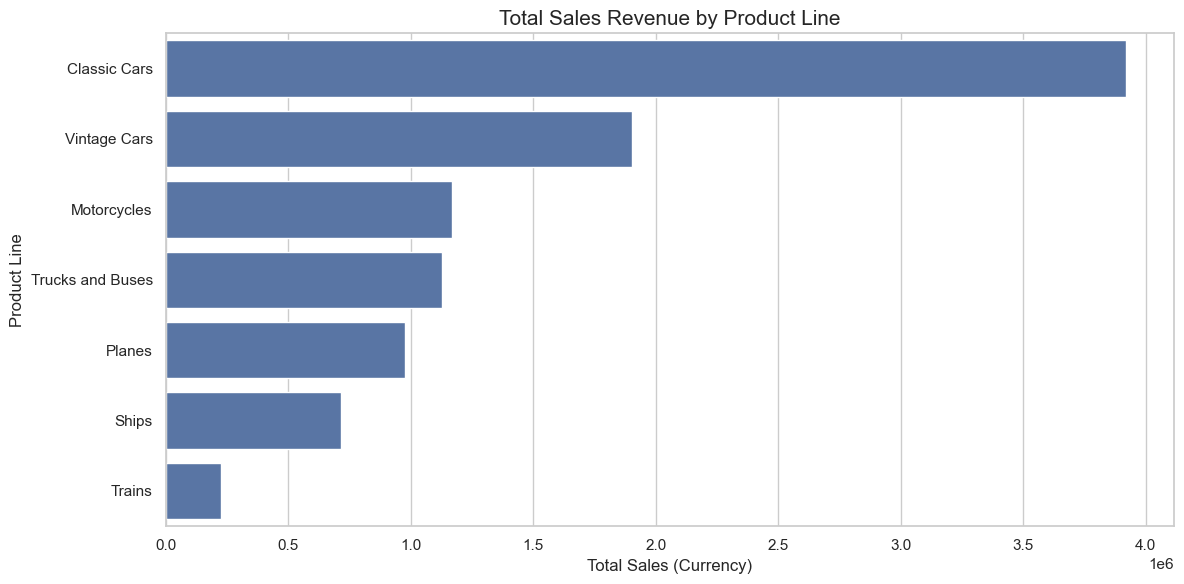

In [389]:
# visualize barchart for sales from different productline
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
plot_data_p = product_summary['SALES']['sum'].sort_values(ascending=False).reset_index()
barplot = sns.barplot(x='sum', y='PRODUCTLINE', data=plot_data_p)
plt.title('Total Sales Revenue by Product Line', fontsize=15)
plt.xlabel('Total Sales (Currency)')
plt.ylabel('Product Line')
plt.tight_layout()
plt.show()

Los Classic Cars (Coches Clásicos) son el pilar de los ingresos, con ventas totales aproximadas de 3.92 millones, superando con creces a las demás categorías.

4.3 Análisis de Tendencias de Ventas:

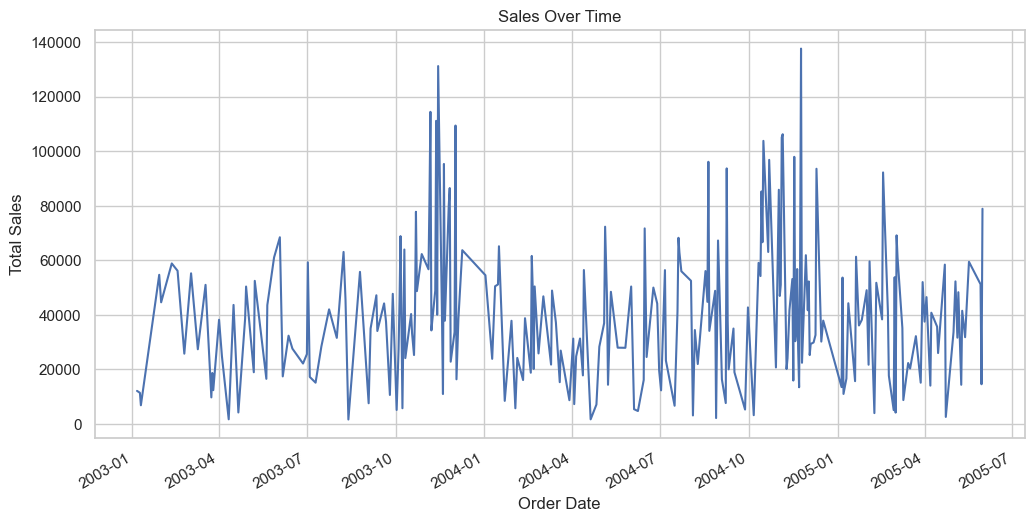

<Figure size 640x480 with 0 Axes>

In [390]:
# linechart to compare the tendency of sales overtime
sales_over_time = df_clean.groupby('ORDERDATE')['SALES'].sum()
plt.figure(figsize=(12, 6))
sales_over_time.plot()
plt.title('Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.show()
plt.savefig('sales_over_time.png')

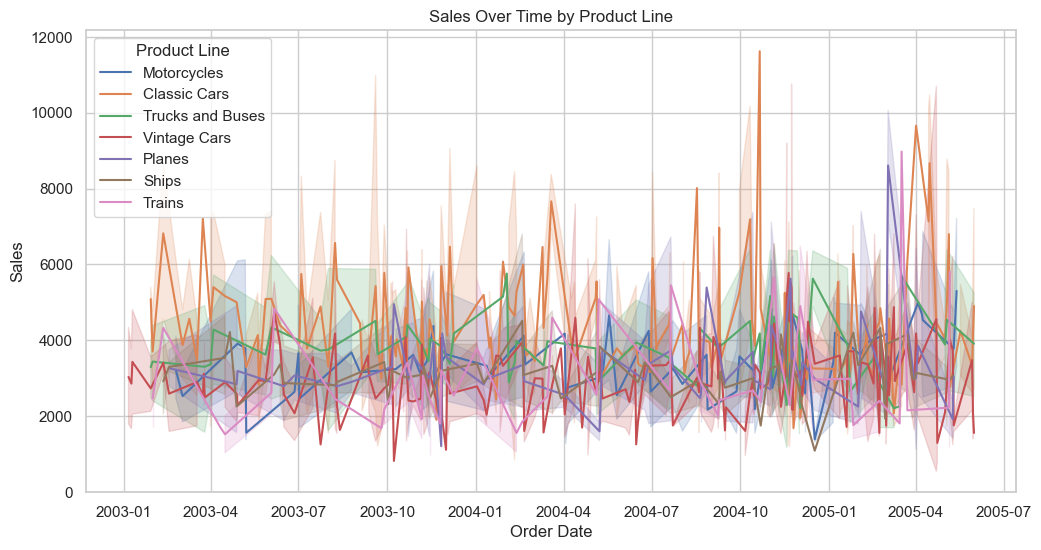

In [391]:
# visualize multiple line plots of sales over time by product line
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x='ORDERDATE', y='SALES', hue='PRODUCTLINE')
plt.title('Sales Over Time by Product Line')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.legend(title='Product Line')
plt.show()

A juzgar por el gráfico de tendencias de ventas de 2003 a 2005:
Volatilidad: Las ventas diarias muestran una fluctuación intensa, con la presencia de picos de venta frecuentes.
Estacionalidad: Se observan picos de ventas extremadamente significativos a finales de 2003 y 2004, con máximos diarios cercanos a los 140,000. Esto coincide plenamente con la estacionalidad de la industria (como el reabastecimiento de inventario a fin de año o las festividades).

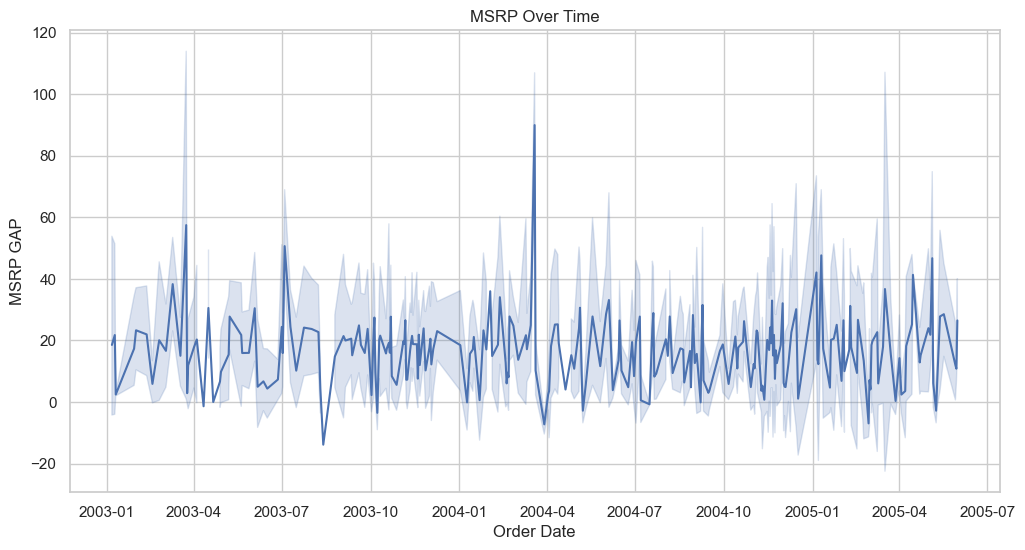

In [392]:
# visualize the the tendency of MSRP GAP over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x='ORDERDATE', y='MSRP GAP')
plt.title('MSRP Over Time')
plt.xlabel('Order Date')
plt.ylabel('MSRP GAP')
plt.show()

El gráfico de tendencia del MSRP GAP revela un patrón de crecimiento estacional impulsado por descuentos. Se observa que el poder de fijación de precios de la plataforma disminuye significativamente durante los picos de ventas, como en el mes de noviembre. De cara al entorno de mercado de 2005, caracterizado por una mayor volatilidad, se recomienda endurecer el proceso de aprobación de descuentos adicionales para los pedidos de gran volumen (High Value Group).

5. Análisis Multivariante Clave:
Esta etapa se centra principalmente en el análisis detallado de la relación entre países y productos, los meses y el volumen de ventas, el precio unitario frente a la cantidad de pedidos, así como el perfilado (profiling) de los valores atípicos de alto valor (High Value).

5.1 Análisis de Preferencias en los 5 Países Líderes en Ventas
Al analizar el comportamiento de compra de los cinco mercados con mayores ingresos, se observan patrones de demanda específicos que definen la identidad de cada mercado.

In [393]:
# Create dataframe for top 5 sales country
top5_list = ['USA', 'Spain', 'France', 'Australia', 'UK']
df_top5_country = df_clean[df_clean['COUNTRY'].isin(top5_list)]

In [394]:
# create a pivot table to see the preference of each country
country_product_pivot = df_top5_country.pivot_table(
    index='COUNTRY', 
    columns='PRODUCTLINE', 
    values='SALES', 
    aggfunc='sum',
    fill_value=0)
country_product_pivot

PRODUCTLINE,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars
COUNTRY,,,,,,,
Australia,193085.54,89968.76,74853.87,4159.76,1681.35,77318.50,189555.32
France,388951.20,226390.31,108155.51,66486.67,27340.80,116982.22,176609.81
Spain,476165.15,74634.82,89985.51,124459.97,43370.18,177556.78,229514.51
UK,159377.70,40802.81,41163.51,72959.17,12635.54,28142.99,123798.74
USA,1344638.22,520371.70,328432.89,209688.14,69253.56,397842.42,757755.90


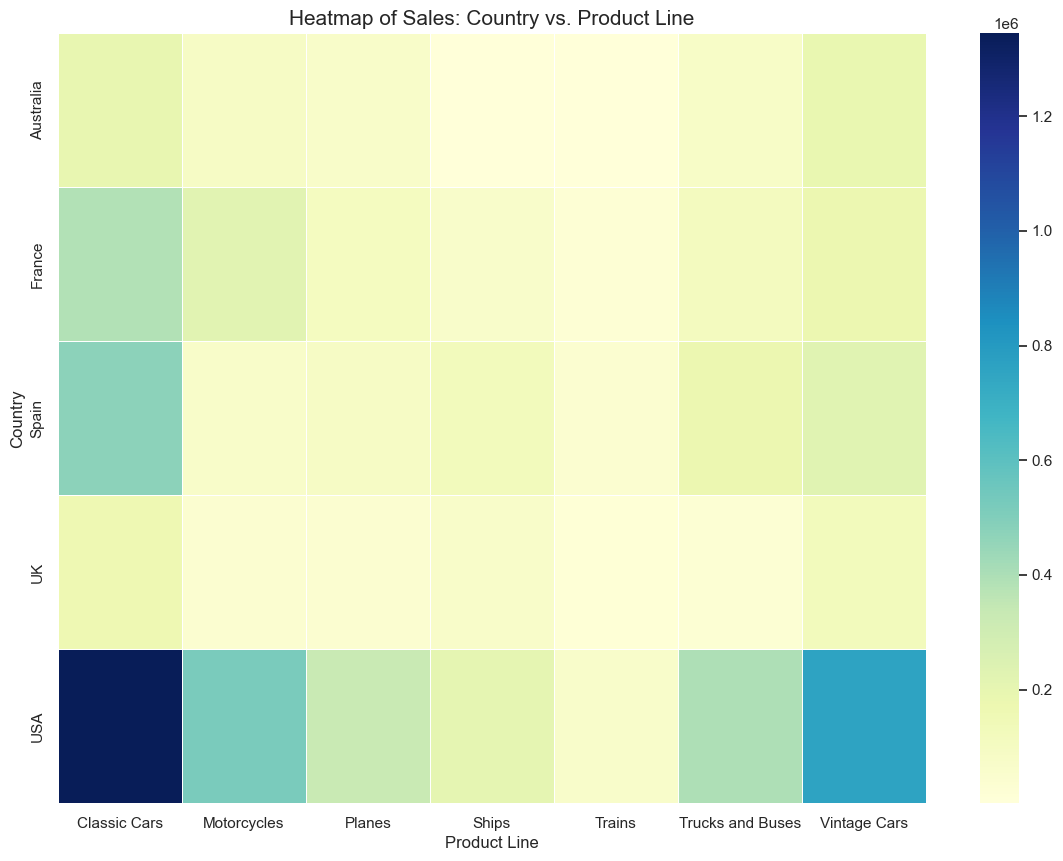

In [395]:
# visualize the correlation between country and product
plt.figure(figsize=(14, 10))
sns.heatmap(
    country_product_pivot, 
    annot=False,      
    cmap='YlGnBu',     
    fmt='.0f',         
    linewidths=0.5)
plt.title('Heatmap of Sales: Country vs. Product Line', fontsize=15)
plt.xlabel('Product Line')
plt.ylabel('Country')
plt.show()

Líneas de Producto (Product Line)
Pilar Principal: Classic Cars lidera la plataforma en todos los mercados. Solo en USA, generó más de 1.34M.
Crecimiento: Vintage Cars es el segundo motor de ingresos. Las Motocicletas destacan con fuerza en USA y Francia.
Complementos (Long Tail): Trenes y Barcos tienen baja aportación y funcionan como productos de nicho.

Mercados Regionales (Country & Territory)
Líder Global: USA domina con el 36.2% de los ingresos totales.
Potencia Regional: EMEA es la región n.º 1 (49.6% del total), impulsada por España (12.1%) y Francia (11.1%).
Oportunidad: Australia lidera en APAC, destacando por un alto valor de compra en coches clásicos y antiguos.

5.2 Estacionalidad Mensual:

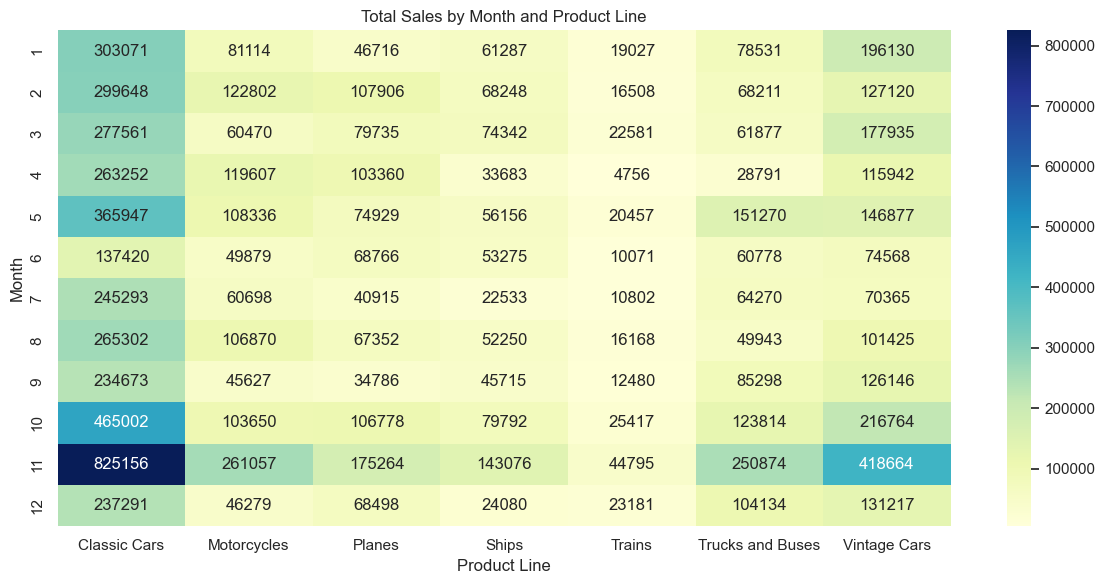

In [396]:
# visualize the relationship between sales, month, and product line using a heatmap
df_clean['MONTH'] = df_clean['ORDERDATE'].dt.month

sales_month_product = df_clean.groupby(['MONTH', 'PRODUCTLINE'])['SALES'].sum()
sales_month_product = sales_month_product.unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(sales_month_product, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title('Total Sales by Month and Product Line')
plt.xlabel('Product Line')
plt.ylabel('Month')
plt.tight_layout()

plt.savefig('sales_by_month_product_line_heatmap.png')  # 建议放在 show 之前
plt.show()


Las ventas muestran una fuerte ciclicidad y un marcado efecto de temporada alta a lo largo del tiempo:
Picos de venta: Se observa un crecimiento explosivo en noviembre de 2003 y noviembre de 2004. En este último periodo, las ventas mensuales de Classic Cars superaron los 825,000.
Patrones estacionales: El cuarto trimestre de cada año (octubre-noviembre) representa un periodo de auge para todas las categorías, mientras que los meses de junio a agosto se mantienen relativamente estables.

5.3 Elasticidad de Precio:Relación entre el precio unitario y la cantidad de pedidos: Análisis de dispersión y tendencia de regresión."

"En este apartado, analizamos la correlación entre el precio unitario (PRICEEACH) y la cantidad solicitada en cada pedido (QUANTITYORDERED). El diagrama de dispersión con línea de regresión nos permite visualizar si existe una elasticidad en la demanda o si el volumen de compra se mantiene constante independientemente del precio.

In [ ]:
# visualize the relationship between price each and quantity ordered using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='PRICEEACH', y='QUANTITYORDERED')
plt.title('Price Each vs Quantity Ordered')
plt.xlabel('Price Each')
plt.ylabel('Quantity Ordered')
plt.show()
plt.savefig('price_each_vs_quantity_ordered.png')

El diagrama de dispersión ilustra claramente el efecto de 'techo de precios' en la plataforma. La densa franja vertical formada en el precio de 100 evidencia una estandarización extrema de los productos. Dado que la distribución de las cantidades por pedido se solapa significativamente en los diferentes niveles de precio, se concluye que la demanda de los clientes es relativamente estable y no muestra una sensibilidad al precio pronunciada. Los escasos valores atípicos de 'alto precio unitario + alta cantidad' representan los factores clave para los picos de ingresos de la plataforma.

5.4 Análisis del Segmento High Value: En esta fase, realizaré el perfilado (profiling) de los clientes de 'Alto Valor' (High Value) dentro de la base de datos, centrándome principalmente en responder: quién compra, cuándo compra y qué compra.

In [ ]:
# create dataframe_high value
df_high_value = df_clean[df_clean['SEGMENTATION']== 'High Value']
df_high_value.head()

In [ ]:
# who: the propotion of the countries
country_sales_high_value = df_high_value.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)
top_n = 8
plot_data_h = country_sales_high_value.head(top_n)
others_sales = country_sales_high_value.iloc[top_n:].sum()
plot_data_h['Others'] = others_sales

plt.figure(figsize=(8, 8))
colors = plt.get_cmap('Pastel1').colors
plt.pie(plot_data_h, 
        labels=plot_data.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        pctdistance=0.85, 
        explode=[0.1 if i == 0 else 0 for i in range(len(plot_data_h))]) 
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Market Share by Country (Sales Revenue) in High Value Group', fontsize=15)
plt.axis('equal') 
plt.tight_layout()
plt.show()

La distribución del grupo de 'Alto Valor' confirma que USA y España son los motores centrales para la generación de márgenes de beneficio en la plataforma.

In [ ]:
# when: the trend of sales over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_high_value, x='ORDERDATE', y='SALES')
plt.title('Sales over time -- high value')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.show()

La tendencia de ventas del grupo de 'Alto Valor' revela que los ingresos de la plataforma se caracterizan por presentar 'puntos de explosión'. Aunque este segmento genera un volumen de pedidos mínimo, cada transacción produce un enorme pulso de ingresos en meses clave (como noviembre). Estos pedidos son una fuente vital de flujo de caja para la plataforma, aunque también presentan un nivel extremadamente alto de imprevisibilidad.

In [ ]:
# what: the propotion of the product
product_sales_high_value = df_high_value.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)
product_sales_high_value

In [ ]:
# visualization of the proportion
plt.figure(figsize=(8, 8))
colors = plt.get_cmap('Pastel1').colors
plt.pie(product_sales_high_value, 
        labels=product_sales_high_value.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        pctdistance=0.85, 
        explode=[0.1 if i == 0 else 0 for i in range(len(product_sales_high_value))]) 
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Market Share by Product (Quantity Ordered) in High Value Group', fontsize=15)
plt.axis('equal') 
plt.tight_layout()
plt.show()

La estructura de compra del grupo de 'Alto Valor' demuestra una tendencia donde 'el fuerte se hace más fuerte'. En comparación con el mercado general, los pedidos de alto valor dependen de forma mucho más agresiva de los Classic Cars (cuya cuota se expande del 39% al 58%), sacrificando la participación de categorías de gama media como las Vintage Cars.

6. Acciones Recomendadas

6.1 Optimización de la Estrategia de Descuentos para "Classic Cars" 
ES: Aunque los Classic Cars son el motor de ingresos, su alto MSRP GAP (mediana 29.76) sugiere una erosión de márgenes. Se recomienda monitorear si los descuentos masivos son necesarios para mantener el volumen o si se puede reducir el GAP en mercados maduros como USA sin sacrificar ventas.

6.2 Replicar el Modelo de Éxito de Australia en la Región APAC
ES: La región APAC solo representa el 12% de las ventas totales, pero Australia muestra una alta propensión a pedidos de alto valor. Se sugiere analizar el perfil de cliente en Australia para capturar oportunidades similares en otros mercados de la región como Japón o Singapur, enfocándose en ventas B2B.

6.3 Explotar el Valor Premium de Categorías Nicho
ES: Categorías como Trains presentan un MSRP GAP negativo o cercano a cero, lo que indica una alta disposición a pagar y poca sensibilidad al precio. Existe una oportunidad para aumentar el MSRP de estos productos nicho o introducir variantes "Premium" para maximizar el beneficio por unidad.

6.4 Gestión de Estacionalidad y Flujo de Caja en Q4
ES: Dado que noviembre es el mes crítico de ventas impulsado por pedidos de alto valor y grandes descuentos, la empresa debe asegurar la cadena de suministro y la liquidez financiera para este periodo. Sin embargo, se debe evitar la dependencia excesiva de los picos de fin de año mediante promociones tácticas en el Q2.

6.5 Monitoreo de Pedidos de Alto Valor (High Value Group)
ES: Los 81 pedidos de alto valor son los "puntos de ráfaga" de ingresos. Se recomienda crear un sistema de gestión de cuentas clave (KAM) para estos clientes, ya que una pequeña fluctuación en este grupo afecta desproporcionadamente a la rentabilidad global.